# Lending Club – Credit Risk EDA
**Dataset:** [All Lending Club Loan Data (Kaggle)](https://www.kaggle.com/datasets/wordsforthewise/lending-club/data)  
**Purpose:** Systematic Exploratory Data Analysis pipeline prior to building a Probability-of-Default (PD) model.

> **Usage note:** Place `accepted_2007_to_2018Q4.csv.gz` (from the Kaggle download) in the same directory as this notebook, then run all cells top-to-bottom.

## 1. Data Understanding

1. Problem Statement
2. Objectives
3. Understanding the Dataset
4. Dataset Attributes
5. Dataset Row Analysis
6. Dataset Column Analysis
7. Handling Missing Data
8. Handling Outliers

### 1.1. Problem Statement

Lending Club, a consumer finance marketplace specialising in offering a variety of loans to urban customers, faces a critical challenge in managing its loan approval process. When evaluating loan applications, the company must make sound decisions to minimise financial losses, primarily stemming from loans extended to applicants who are considered "risky."

These financial losses, referred to as credit losses, occur when borrowers fail to repay their loans or default. In simpler terms, borrowers labelled as "charged-off" are the ones responsible for the most significant losses to the company.

The primary objective of this exercise is to assist Lending Club in mitigating credit losses. This challenge arises from two potential scenarios:
1. Identifying applicants likely to repay their loans is crucial, as they can generate profits for the company through interest payments. Rejecting such applicants would result in a loss of potential business.
2. On the other hand, approving loans for applicants not likely to repay and at risk of default can lead to substantial financial losses for the company.

### 1.2. Objectives

The objective is to pinpoint applicants at risk of defaulting on loans, enabling a reduction in credit losses. This case study aims to achieve this goal through Exploratory Data Analysis (EDA) on the accepted-loans dataset (2012–2018).

In essence, the company wants to understand the driving factors (or driver variables) behind loan default — i.e. the variables which are strong indicators of default. The company can utilise this knowledge for its portfolio and risk assessment.

This EDA pipeline precedes the construction of a Probability-of-Default (PD) model.

### 1.3. Understanding the Dataset

This dataset contains information about accepted loan applications from Lending Club for the period 2007–2018 Q4. For this analysis we restrict to **matured loans** only:
- **Fully Paid** — borrower has repaid the loan in full.
- **Charged Off** — borrower has defaulted; the loan is considered a loss.

Loans with statuses such as "Current", "In Grace Period", or "Late" are excluded because their final outcome is not yet known.

Additionally, pre-2012 rows are dropped because Lending Club added many columns progressively after 2012, leading to high sparsity in earlier data.

A binary target variable `default` is created: **1 = Charged Off**, **0 = Fully Paid**.

### 1.4. Dataset Attributes

#### Primary Attribute
- **Loan Status** (`loan_status`): The principal attribute of interest. After filtering, it takes two values:
    - *Fully Paid* — customer successfully repaid the loan.
    - *Charged Off* — customer defaulted; mapped to `default = 1`.

#### Derived Target
- **`default`** (binary, 0/1): created from `loan_status == "Charged Off"`.

### 1.5. Dataset Row Analysis

- **Header & Footer Rows:** No header or footer rows in the dataset beyond the standard CSV header.
- **Extra Rows:** No row-number indicators or summary rows present.
- **Filtering:** Only matured loans (Fully Paid / Charged Off) are retained — pre-2012 rows are dropped due to high column sparsity in that era.
- After filtering, the working dataset covers **2012–2018** and contains only loans with a resolved outcome.

### 1.6. Dataset Column Analysis

The raw dataset contains 151 columns. After structural analysis:
- Columns with **>60% missing values** are dropped — these carry insufficient information for analysis or modelling.
- Identifier / free-text columns (`id`, `member_id`, `url`, `desc`, `emp_title`) are excluded from modelling but retained in the DataFrame for traceability.
- The remaining columns are organised into semantic **feature groups**: loan terms, borrower attributes, credit history, payment history, and flags.

### 1.7. Handling Missing Data

- **Dropping Columns:** Columns with more than **60% missing values** are removed entirely — they contribute little signal and inflate the feature space.
- **Numeric nulls:** For low-missingness numeric columns, values are left as-is for the EDA phase; imputation strategies (median, model-based) are deferred to the modelling phase.
- The missingness audit is visualised as a horizontal bar chart of the top-30 columns by null percentage.

### 1.8. Handling Outliers

Extreme outliers are known to exist in:
- `annual_inc` — a small number of borrowers report very high incomes (> $1 M).
- `dti` — some debt-to-income ratios are implausibly large.

For EDA visualisations, outliers are handled by **clipping at the 99th percentile** within each plot, preserving the full dataset for aggregate statistics while preventing visual distortion.

## 2. Data Cleaning and Manipulation

1. Loading Data from CSV
2. Checking for Null Values
3. Dropping High-Null Columns
4. Checking for Unique Values
5. Target Variable Creation
6. Feature Group Definitions
7. Leakage Column Flagging

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Imports complete.")

Imports complete.


### 2.1. Loading Data from CSV

We load the accepted-loans CSV, immediately restrict to matured loans (Fully Paid / Charged Off), drop pre-2012 rows, and create the binary target `default`.

In [2]:
DATA_PATH = r"C:\Users\User\Downloads\Credit Risk\accepted_2007_to_2018Q4.csv\accepted_2007_to_2018Q4.csv"

def load_data(path):
    df = pd.read_csv(
        path,
        parse_dates=["issue_d", "last_pymnt_d", "earliest_cr_line"],
    )
    print(f"  Raw shape: {df.shape}")

    # Keep only matured loans
    matured = ["Fully Paid", "Charged Off"]
    df = df[df["loan_status"].isin(matured)].copy()

    # Drop pre-2012 (sparse columns)
    if "issue_d" in df.columns:
        df = df[df["issue_d"] >= "2012-01-01"]

    # Binary target
    df["default"] = (df["loan_status"] == "Charged Off").astype(int)
    print(f"  Matured + post-2012 shape: {df.shape}")
    return df

df = load_data(DATA_PATH)
df.head(3)

  Raw shape: (2260701, 151)
  Matured + post-2012 shape: (1305524, 152)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


### 2.2. Checking for Null Values

Build a missingness map and dtype inventory — O(n × p) pass over the dataset.

In [3]:
null_pct = df.isnull().mean().sort_values(ascending=False)
dtype_map = df.dtypes

audit = pd.DataFrame({
    "null_pct": null_pct,
    "dtype":    dtype_map[null_pct.index],
    "n_unique": df[null_pct.index].nunique(),
})

print(f"Total columns: {len(audit)}")
print(f"Columns with >60% missing: {(audit['null_pct'] > 0.60).sum()}")
audit.head(20)

Total columns: 152
Columns with >60% missing: 44


,null_pct,dtype,n_unique
member_id,1.000000,float64,0
next_pymnt_d,1.000000,object,0
orig_projected_additional_accrued_interest,0.997121,float64,3480
hardship_amount,0.995593,float64,5182
hardship_last_payment_amount,0.995593,float64,5048
hardship_length,0.995593,float64,1
hardship_status,0.995593,object,2
hardship_reason,0.995593,object,9
deferral_term,0.995593,float64,1
hardship_start_date,0.995593,object,26


### 2.3. Dropping High-Null Columns

All columns with more than 60% missing values are removed, then the top-30 missingness profile is visualised.

  Columns dropped: 44
  Shape after dropping high-null cols: (1305524, 108)


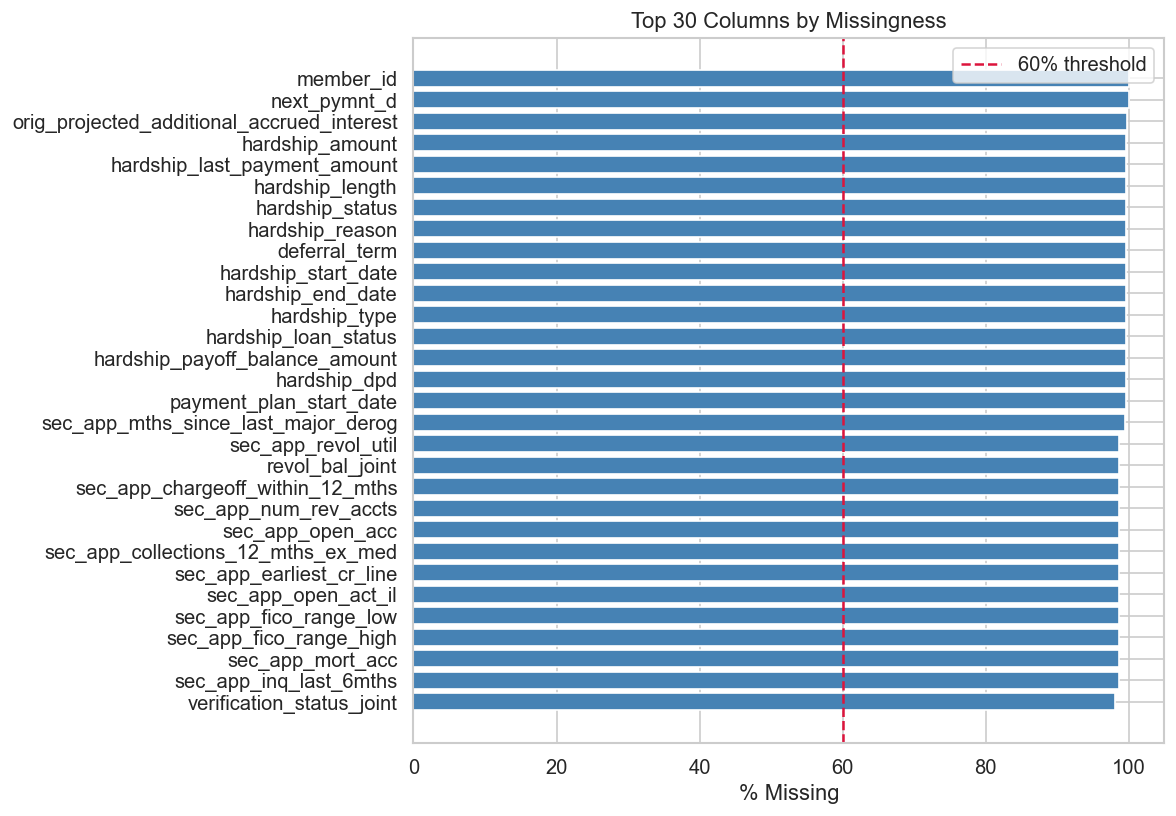

In [4]:
high_null = audit[audit["null_pct"] > 0.60]
df = df.drop(columns=high_null.index.tolist())
print(f"  Columns dropped: {len(high_null)}")
print(f"  Shape after dropping high-null cols: {df.shape}")

# Visualise top-30 missing
top30 = audit.head(30)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top30.index[::-1], top30["null_pct"][::-1] * 100, color="steelblue")
ax.axvline(60, color="crimson", linestyle="--", label="60% threshold")
ax.set_xlabel("% Missing")
ax.set_title("Top 30 Columns by Missingness")
ax.legend()
plt.tight_layout()
plt.savefig("01_missingness.png", bbox_inches="tight")
plt.show()

###### Columns exceeding the 60% missingness threshold have been dropped. The remaining columns have sufficient data coverage for EDA and downstream modelling.

### 2.4. Checking for Unique Values

Inspect cardinality of remaining columns to identify quasi-constant or high-cardinality features.

In [5]:
nunique = df.nunique().sort_values()
print("Columns with only 1 unique value (quasi-constant):")
print(nunique[nunique == 1].index.tolist())
print()
print("Columns with very high cardinality (>10,000 unique values):")
print(nunique[nunique > 10000].index.tolist())
nunique

Columns with only 1 unique value (quasi-constant):
['pymnt_plan', 'policy_code', 'out_prncp_inv', 'out_prncp', 'hardship_flag']

Columns with very high cardinality (>10,000 unique values):
['tot_coll_amt', 'total_rec_late_fee', 'total_bc_limit', 'total_rev_hi_lim', 'max_bal_bc', 'title', 'annual_inc', 'bc_open_to_buy', 'avg_cur_bal', 'installment', 'revol_bal', 'total_bal_il', 'recoveries', 'collection_recovery_fee', 'total_il_high_credit_limit', 'total_bal_ex_mort', 'total_rec_prncp', 'emp_title', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_rec_int', 'last_pymnt_amnt', 'total_pymnt_inv', 'total_pymnt', 'id', 'url']


pymnt_plan               1
policy_code              1
out_prncp_inv            1
out_prncp                1
hardship_flag            1
                    ...   
last_pymnt_amnt     682287
total_pymnt_inv     988283
total_pymnt        1223177
id                 1305524
url                1305524
Length: 108, dtype: int64

### 2.5. Target Variable Creation

The binary target `default` was created during loading. Here we inspect its distribution to understand class imbalance.

In [6]:
counts = df["default"].value_counts()
pcts   = df["default"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "pct": pcts})
summary.index = ["Non-Default (0)", "Default (1)"]
print(summary.to_string())
print(f"\nImbalance ratio (non-default:default) = {counts[0]/counts[1]:.1f}:1")

                   count        pct
Non-Default (0)  1042635  79.863335
Default (1)       262889  20.136665

Imbalance ratio (non-default:default) = 4.0:1


### 2.6. Feature Group Definitions

Organise the remaining columns into semantic buckets before profiling. This aids interpretability and ensures leakage columns are easily identified.

In [7]:
FEATURE_GROUPS = {
    "loan_terms":    ["loan_amnt", "funded_amnt", "term", "int_rate",
                       "installment", "purpose", "grade", "sub_grade"],
    "borrower":      ["emp_length", "emp_title", "home_ownership",
                       "annual_inc", "verification_status", "addr_state", "zip_code"],
    "credit_history":["fico_range_low", "fico_range_high", "dti",
                       "delinq_2yrs", "pub_rec", "open_acc", "total_acc",
                       "revol_bal", "revol_util", "earliest_cr_line"],
    "payment":       ["total_pymnt", "total_rec_prncp", "total_rec_int",
                       "total_rec_late_fee", "recoveries", "out_prncp",
                       "last_pymnt_amnt"],
    "flags":         ["hardship_flag", "debt_settlement_flag", "pymnt_plan",
                       "disbursement_method"],
}

print("Feature group sizes:")
for g, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in df.columns]
    print(f"  {g:20s}: {len(present)}/{len(cols)} present")

Feature group sizes:
  loan_terms          : 8/8 present
  borrower            : 7/7 present
  credit_history      : 10/10 present
  payment             : 7/7 present
  flags               : 4/4 present


### 2.7. Leakage Column Flagging

Post-origination columns that are only known after loan resolution must NOT be used as model features. They are flagged here for exclusion from any downstream model.

In [8]:
LEAKAGE_COLS = [
    "recoveries", "collection_recovery_fee", "total_rec_late_fee",
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "last_pymnt_amnt",
    "last_pymnt_d", "next_pymnt_d",
]

present_leakage = [c for c in LEAKAGE_COLS if c in df.columns]
print(f"Leakage columns flagged: {len(LEAKAGE_COLS)}")
print(f"Leakage columns present in current dataset: {len(present_leakage)}")
for c in present_leakage:
    pct_null = df[c].isnull().mean() * 100
    print(f"  {c:<40s}  null={pct_null:.1f}%")
print("\nThese will be excluded from any downstream model.")

Leakage columns flagged: 12
Leakage columns present in current dataset: 11
  recoveries                                null=0.0%
  collection_recovery_fee                   null=0.0%
  total_rec_late_fee                        null=0.0%
  out_prncp                                 null=0.0%
  out_prncp_inv                             null=0.0%
  total_pymnt                               null=0.0%
  total_pymnt_inv                           null=0.0%
  total_rec_prncp                           null=0.0%
  total_rec_int                             null=0.0%
  last_pymnt_amnt                           null=0.0%
  last_pymnt_d                              null=0.2%

These will be excluded from any downstream model.


## 3. Exploratory Data Analysis

1. Target Variable Analysis (Class Imbalance)
2. Univariate Analysis – Continuous Features
3. Univariate Analysis – Categorical Features
4. Bivariate Analysis – Default Drivers
5. Temporal Analysis
6. Correlation & Multicollinearity

### 3.1. Target Variable Analysis (Class Imbalance)

Examine the class imbalance between default / non-default. Understanding this ratio is critical for choosing an appropriate evaluation metric and sampling strategy.

*Complexity: O(n) — single groupby count.*

                   count        pct
Non-Default (0)  1042635  79.863335
Default (1)       262889  20.136665


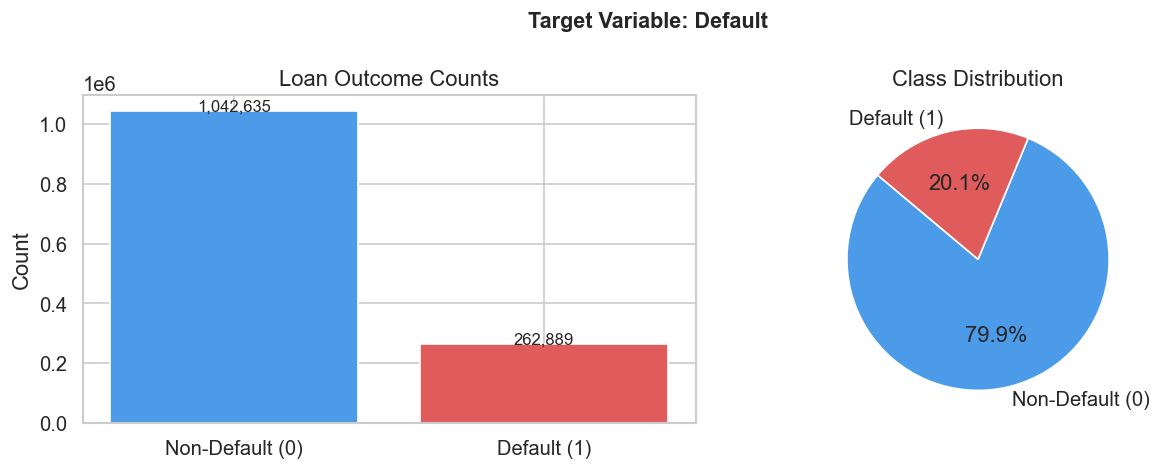

Imbalance ratio (non-default:default) = 4.0:1


In [9]:
counts = df["default"].value_counts()
pcts   = df["default"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "pct": pcts})
summary.index = ["Non-Default (0)", "Default (1)"]
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
axes[0].bar(summary.index, summary["count"], color=["#4c9be8", "#e05c5c"])
axes[0].set_title("Loan Outcome Counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(summary["count"]):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

# Pie
axes[1].pie(summary["count"], labels=summary.index,
            autopct="%1.1f%%", colors=["#4c9be8", "#e05c5c"],
            startangle=140, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Class Distribution")

plt.suptitle("Target Variable: Default", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("02_target.png", bbox_inches="tight")
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"Imbalance ratio (non-default:default) = {imbalance_ratio:.1f}:1")

###### The dataset is significantly imbalanced — non-defaults far outnumber defaults. Log-loss / AUC are recommended as evaluation metrics; SMOTE or class-weighted models should be considered for training.

### 3.2. Univariate Analysis – Continuous Features

Distribution plots for key continuous features to understand their spread, skew, and presence of outliers.

*Complexity: O(n) per column histogram.*

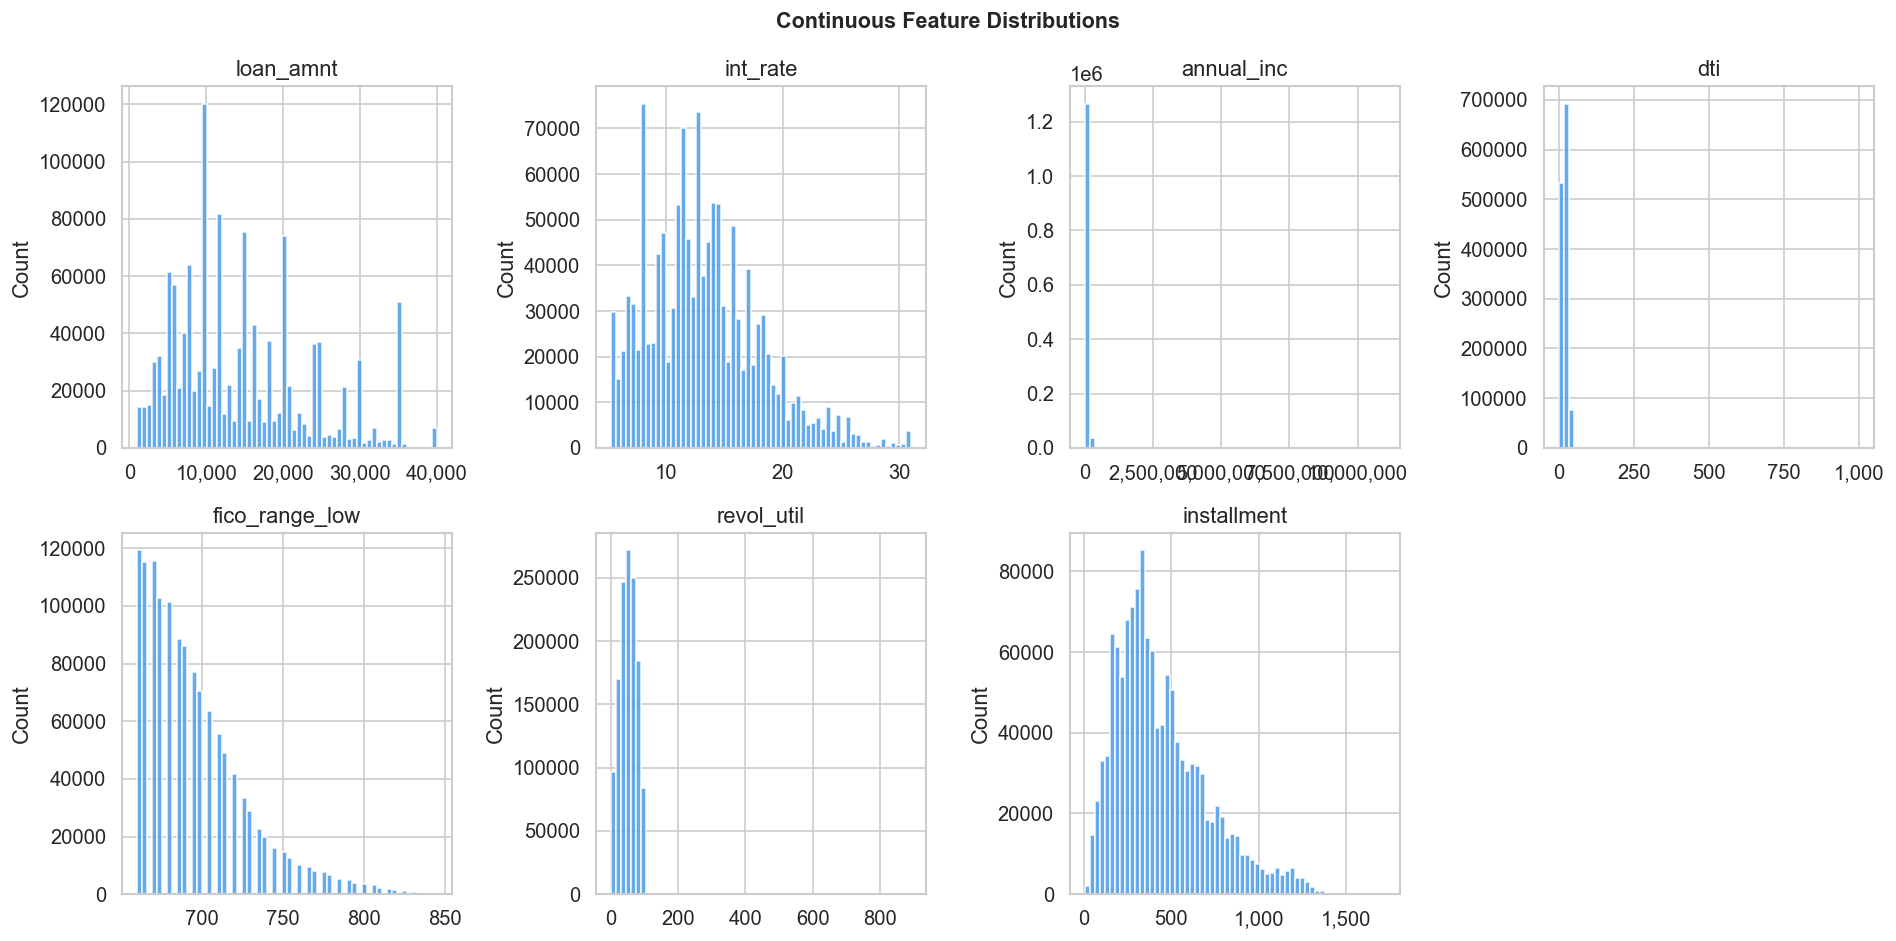

In [10]:
cont_cols = ["loan_amnt", "int_rate", "annual_inc", "dti",
             "fico_range_low", "revol_util", "installment"]
cont_cols = [c for c in cont_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cont_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color="#4c9be8", edgecolor="white", alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:,.0f}"))
for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Continuous Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("04a_univariate_continuous.png", bbox_inches="tight")
plt.show()

###### Most continuous features are right-skewed. `annual_inc` and `dti` show extreme outliers; clipping at the 99th percentile is applied in bivariate plots. `fico_range_low` is approximately normally distributed.

In [11]:
# Descriptive statistics for continuous features
df[cont_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1305524.0,14517.15,8734.15,1000.00,8000.00,12000.00,20000.00,40000.00
int_rate,1305524.0,13.28,4.79,5.31,9.75,12.74,16.02,30.99
annual_inc,1305524.0,76469.15,70092.58,0.00,46000.00,65000.00,90045.00,10999200.00
dti,1305150.0,18.43,11.23,-1.00,11.93,17.76,24.25,999.00
fico_range_low,1305524.0,695.61,31.55,660.00,670.00,690.00,710.00,845.00
revol_util,1304717.0,51.90,24.39,0.00,33.60,52.20,70.70,892.30
installment,1305524.0,441.53,262.18,4.93,251.31,377.37,585.29,1719.83


### 3.3. Univariate Analysis – Categorical Features

Count distributions for key categorical features.

*Complexity: O(n) per value_counts call.*

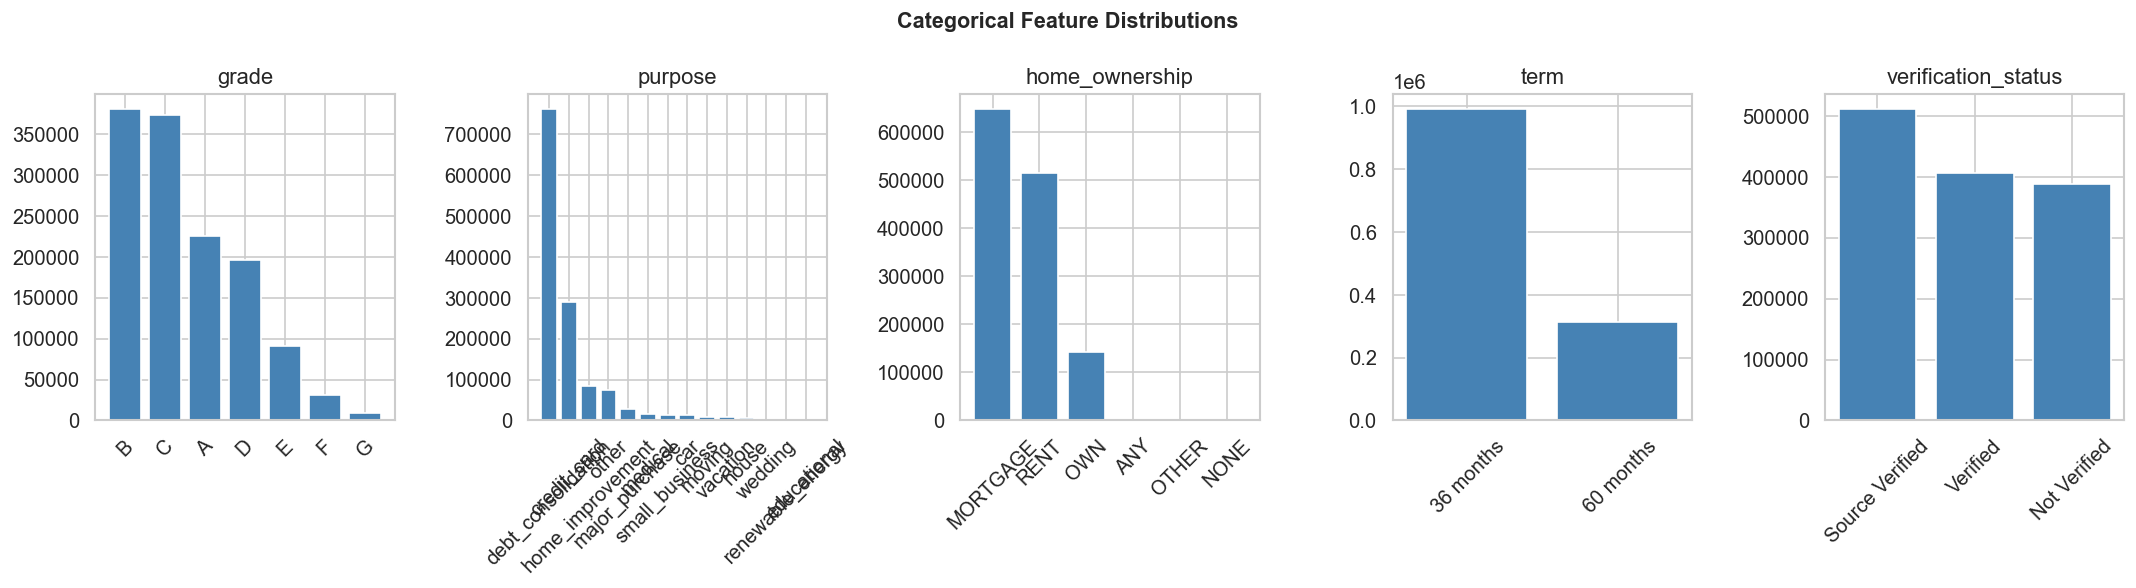

In [12]:
cat_cols = ["grade", "purpose", "home_ownership", "term", "verification_status"]
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)
plt.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("04b_univariate_categorical.png", bbox_inches="tight")
plt.show()

###### Grade B and C loans dominate the portfolio. Debt consolidation is the most common loan purpose. Most borrowers rent or have a mortgage. The 36-month term is far more common than 60-month.

### 3.4. Bivariate Analysis – Default Drivers

For each key feature, compute the **default rate** conditional on that feature to identify the strongest predictors.

*Complexity: O(n) per groupby operation.*

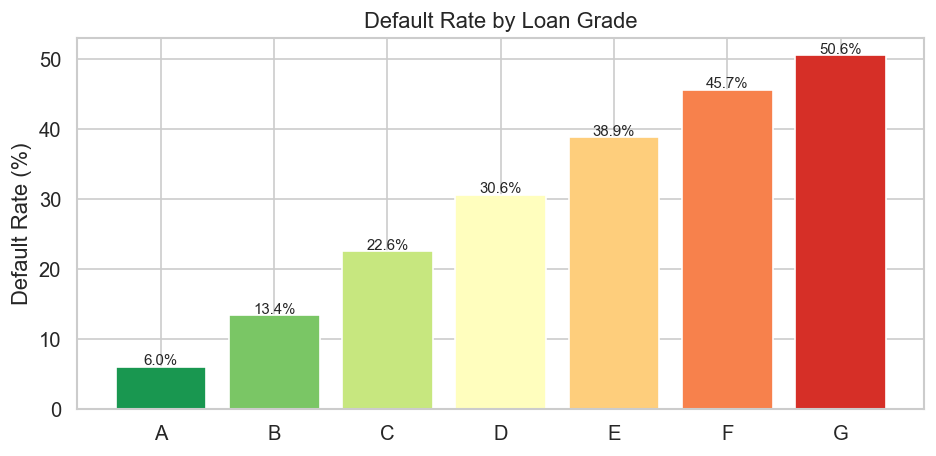

In [13]:
# 3.4a: Default rate by Grade
if "grade" in df.columns:
    grade_dr = df.groupby("grade")["default"].mean().sort_index() * 100
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(grade_dr.index, grade_dr.values,
                  color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grade_dr))))
    ax.set_ylabel("Default Rate (%)")
    ax.set_title("Default Rate by Loan Grade")
    for bar, val in zip(bars, grade_dr.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f"{val:.1f}%", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("05a_grade_default.png", bbox_inches="tight")
    plt.show()

###### Default rate increases monotonically from Grade A to Grade G, confirming that Lending Club's internal grade is a strong risk signal. Grade G loans default at roughly 3–4× the rate of Grade A loans.

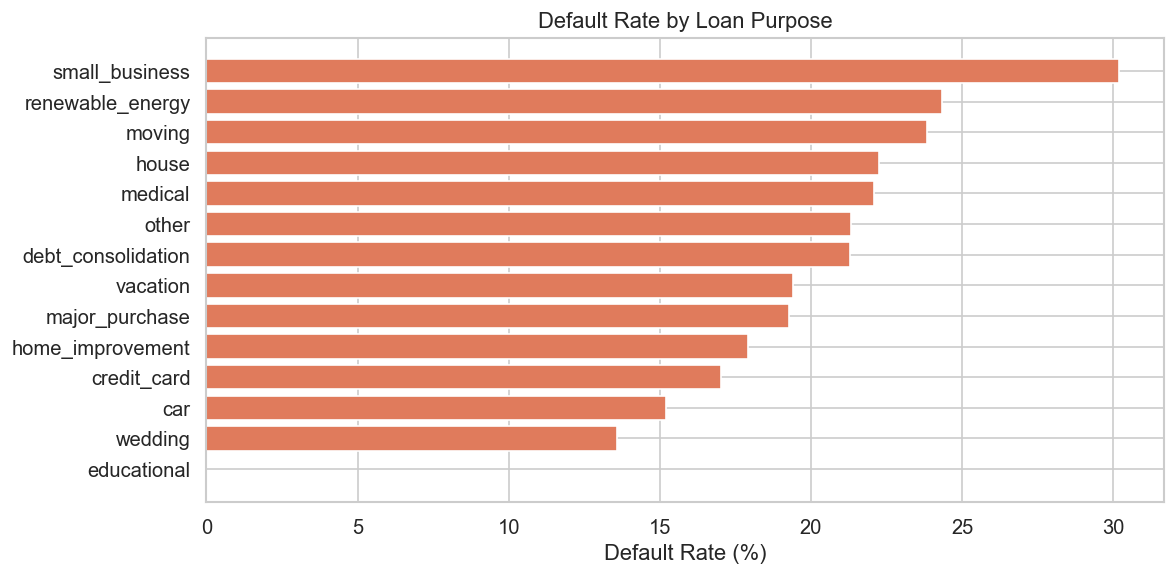

In [14]:
# 3.4b: Default rate by Loan Purpose
if "purpose" in df.columns:
    purpose_dr = (df.groupby("purpose")["default"]
                    .mean().sort_values(ascending=False) * 100)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(purpose_dr.index[::-1], purpose_dr.values[::-1], color="#e07b5c")
    ax.set_xlabel("Default Rate (%)")
    ax.set_title("Default Rate by Loan Purpose")
    plt.tight_layout()
    plt.savefig("05b_purpose_default.png", bbox_inches="tight")
    plt.show()

###### Small business loans have the highest default rate. Debt consolidation, while the most common purpose, has an intermediate default rate.

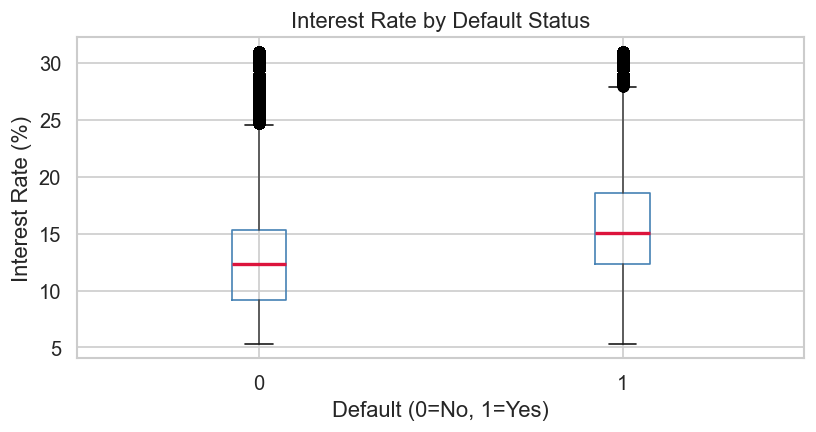

In [15]:
# 3.4c: Interest rate vs default (boxplot)
if "int_rate" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    df.boxplot(column="int_rate", by="default", ax=ax,
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="crimson", linewidth=2))
    ax.set_title("Interest Rate by Default Status")
    ax.set_xlabel("Default (0=No, 1=Yes)")
    ax.set_ylabel("Interest Rate (%)")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("05c_intrate_default.png", bbox_inches="tight")
    plt.show()

###### Defaulted loans have a notably higher median interest rate. This is expected — riskier borrowers are charged higher rates — but also confirms `int_rate` as a strong default predictor.

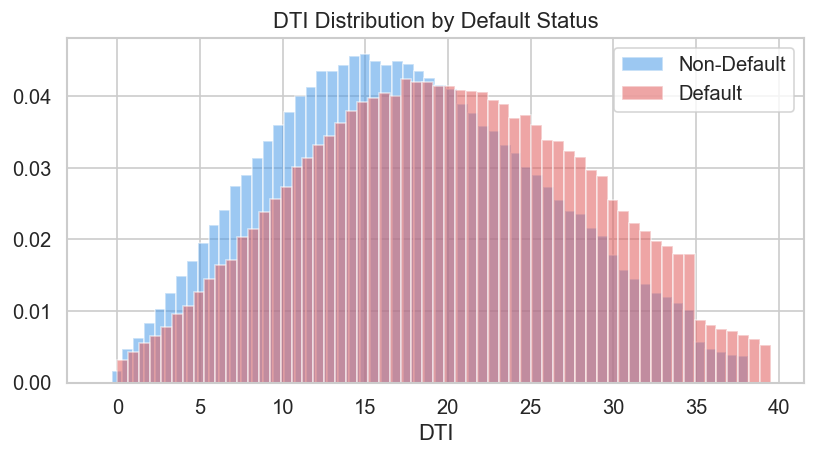

In [16]:
# 3.4d: DTI distribution by default
if "dti" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    for val, label, color in [(0, "Non-Default", "#4c9be8"), (1, "Default", "#e05c5c")]:
        data = df[df["default"] == val]["dti"].dropna()
        data = data[data < data.quantile(0.99)]  # clip extreme outliers
        ax.hist(data, bins=60, alpha=0.55, label=label, color=color, density=True)
    ax.set_xlabel("DTI")
    ax.set_title("DTI Distribution by Default Status")
    ax.legend()
    plt.tight_layout()
    plt.savefig("05d_dti_default.png", bbox_inches="tight")
    plt.show()

###### Defaulters tend to have slightly higher DTI values, though the distributions overlap substantially. DTI alone is not a strong discriminator but contributes in combination with other features.

Default rate by term:
term
36 months    16.137295
60 months    32.772073


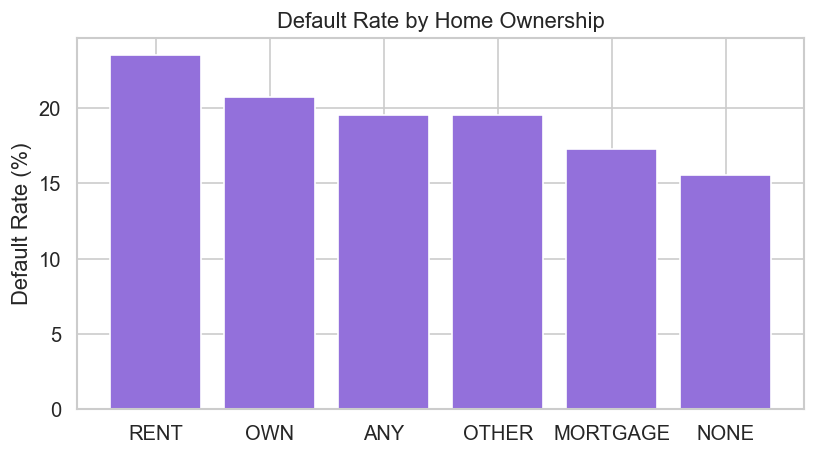

In [17]:
# 3.4e: Default rate by loan term
if "term" in df.columns:
    term_dr = df.groupby("term")["default"].mean() * 100
    print("Default rate by term:")
    print(term_dr.to_string())

# 3.4f: Default rate by home ownership
if "home_ownership" in df.columns:
    ho_dr = (df.groupby("home_ownership")["default"]
               .mean().sort_values(ascending=False) * 100)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(ho_dr.index, ho_dr.values, color="mediumpurple", edgecolor="white")
    ax.set_ylabel("Default Rate (%)")
    ax.set_title("Default Rate by Home Ownership")
    plt.tight_layout()
    plt.savefig("05e_homeownership_default.png", bbox_inches="tight")
    plt.show()

###### 60-month term loans default at a significantly higher rate than 36-month loans. Borrowers who rent default slightly more often than those with a mortgage or own their home outright.

### 3.5. Temporal Analysis

Examine non-stationarity of key metrics over time — default rate, loan volume, and DTI trends by year and month.

*Complexity: O(n log n) due to groupby + sort on date index.*

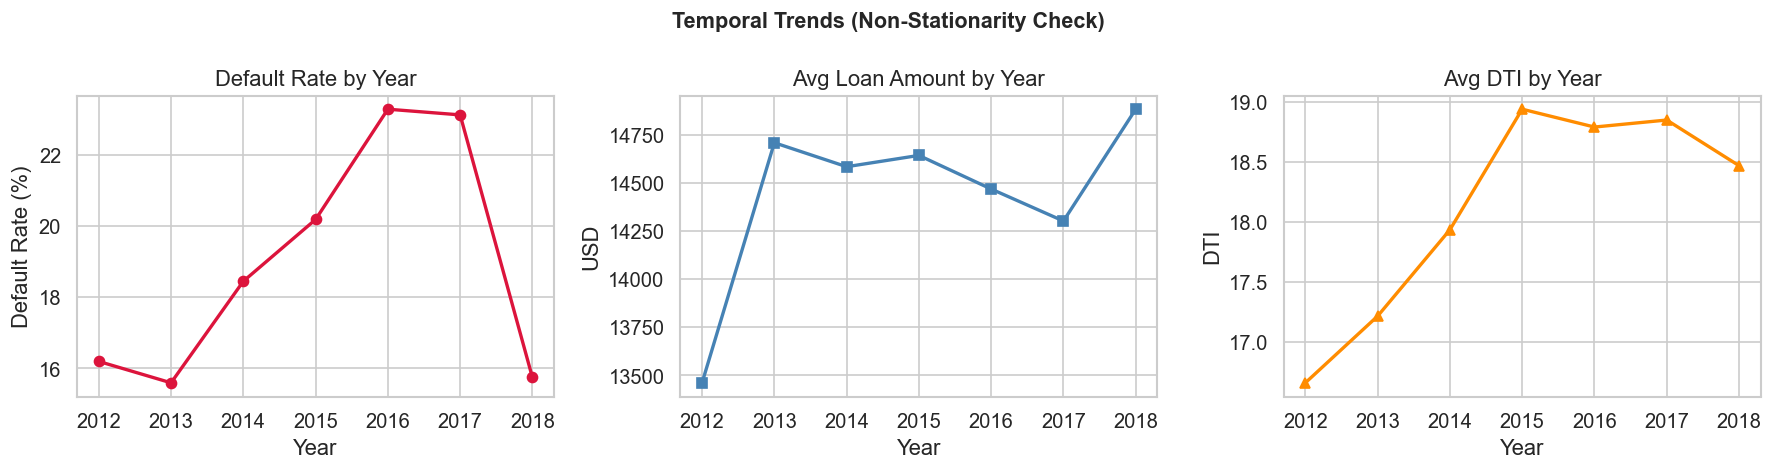

In [18]:
if "issue_d" not in df.columns:
    print("issue_d column not found – skipping temporal analysis.")
else:
    ts = df.copy()
    ts["year"] = ts["issue_d"].dt.year

    yr_dr = ts.groupby("year")["default"].mean() * 100

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Default rate over years
    axes[0].plot(yr_dr.index, yr_dr.values, marker="o", color="crimson", linewidth=2)
    axes[0].set_title("Default Rate by Year")
    axes[0].set_ylabel("Default Rate (%)")
    axes[0].set_xlabel("Year")

    # Average loan amount over years
    if "loan_amnt" in ts.columns:
        yr_amt = ts.groupby("year")["loan_amnt"].mean()
        axes[1].plot(yr_amt.index, yr_amt.values, marker="s", color="steelblue", linewidth=2)
        axes[1].set_title("Avg Loan Amount by Year")
        axes[1].set_ylabel("USD")
        axes[1].set_xlabel("Year")

    # Average DTI over years
    if "dti" in ts.columns:
        yr_dti = ts.groupby("year")["dti"].mean()
        axes[2].plot(yr_dti.index, yr_dti.values, marker="^", color="darkorange", linewidth=2)
        axes[2].set_title("Avg DTI by Year")
        axes[2].set_ylabel("DTI")
        axes[2].set_xlabel("Year")

    plt.suptitle("Temporal Trends (Non-Stationarity Check)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("06_temporal.png", bbox_inches="tight")
    plt.show()

###### Default rate, average loan amount, and average DTI all shift over time — confirming non-stationarity in the dataset. Out-of-time validation splits should be used rather than random train/test splits.

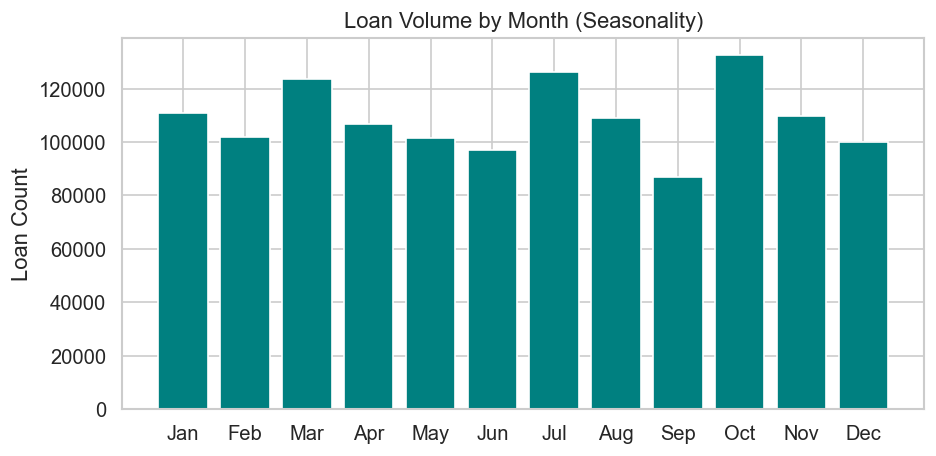

In [19]:
# Seasonal (monthly) loan volume
if "issue_d" in df.columns:
    ts = df.copy()
    ts["month"] = ts["issue_d"].dt.month
    monthly_vol = ts.groupby("month").size()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(monthly_vol.index, monthly_vol.values, color="teal", edgecolor="white")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])
    ax.set_title("Loan Volume by Month (Seasonality)")
    ax.set_ylabel("Loan Count")
    plt.tight_layout()
    plt.savefig("06b_seasonal.png", bbox_inches="tight")
    plt.show()

###### Q4 (October–December) shows the highest loan origination volume, with December being the peak month. This seasonality should be accounted for in any time-based feature engineering.

### 3.6. Correlation & Multicollinearity

Build a correlation heatmap on numeric candidate features (excluding leakage columns) and flag highly correlated pairs.

*Complexity: O(p²·n) for full correlation matrix computation.*

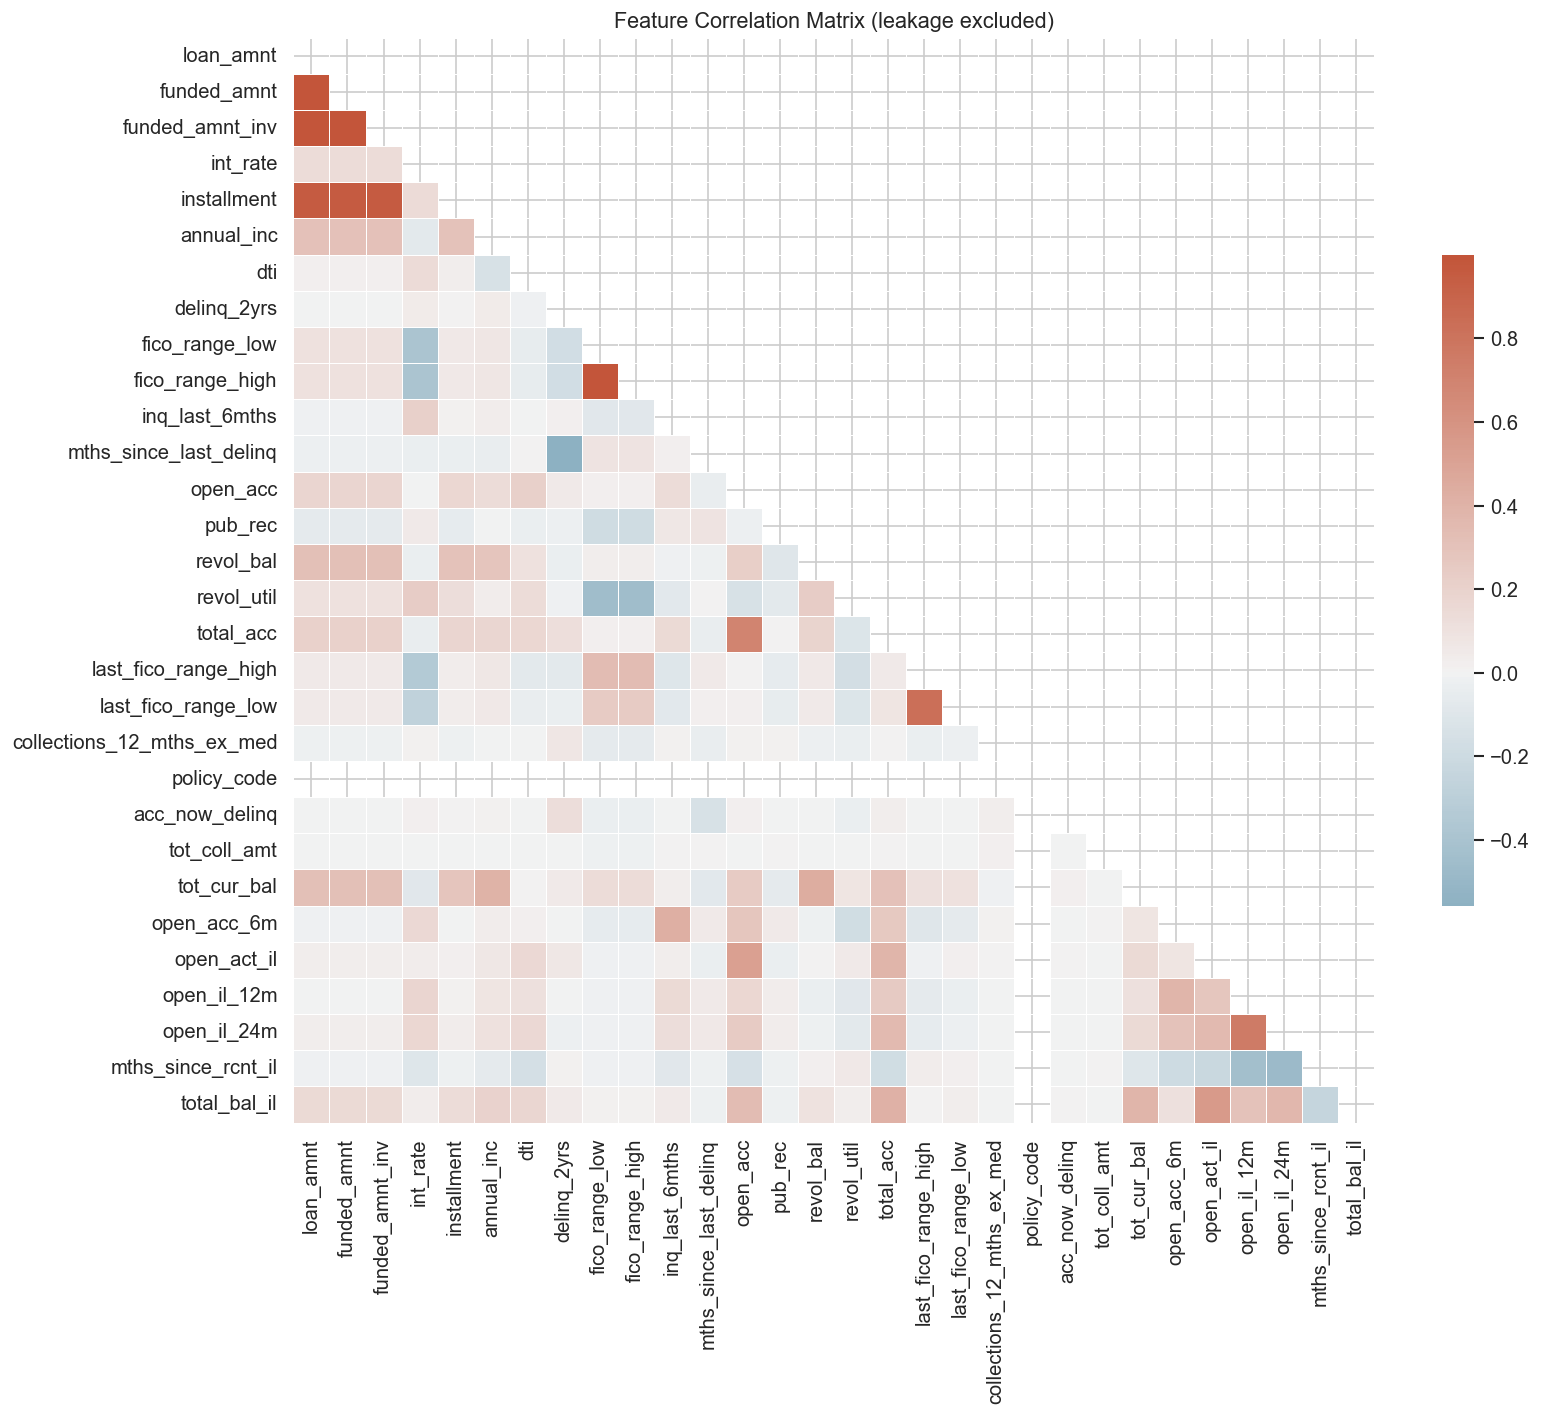

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove leakage and target
safe_cols = [c for c in numeric_cols
             if c not in LEAKAGE_COLS and c != "default"][:30]  # cap at 30 for readability

corr_matrix = df[safe_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=False, linewidths=0.4, ax=ax,
            cbar_kws={"shrink": 0.6})
ax.set_title("Feature Correlation Matrix (leakage excluded)", fontsize=13)
plt.tight_layout()
plt.savefig("07_correlation.png", bbox_inches="tight")
plt.show()

In [21]:
# Flag high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.75:
            high_corr_pairs.append({
                "feature_1": corr_matrix.columns[i],
                "feature_2": corr_matrix.columns[j],
                "correlation": round(val, 3),
            })
hcp_df = pd.DataFrame(high_corr_pairs).sort_values("correlation",
                       key=abs, ascending=False)
print(f"Highly correlated pairs (|r| > 0.75): {len(hcp_df)}")
hcp_df

Highly correlated pairs (|r| > 0.75): 9


,feature_1,feature_2,correlation
0,loan_amnt,funded_amnt,1.000
1,loan_amnt,funded_amnt_inv,1.000
3,funded_amnt,funded_amnt_inv,1.000
6,fico_range_low,fico_range_high,1.000
2,loan_amnt,installment,0.954
4,funded_amnt,installment,0.954
5,funded_amnt_inv,installment,0.954
7,last_fico_range_high,last_fico_range_low,0.829
8,open_il_12m,open_il_24m,0.754


###### Several numeric features are highly correlated (e.g. `loan_amnt` / `funded_amnt` / `installment`). In a downstream model, one from each highly correlated pair should be dropped or dimensionality reduction applied.

## 4. Summary & Findings

1. EDA Summary Dashboard
2. Key Findings Report

### 4.1. EDA Summary Dashboard

Consolidated 6-panel summary figure of the most important EDA findings.

*Complexity: O(n) for the final group aggregations.*

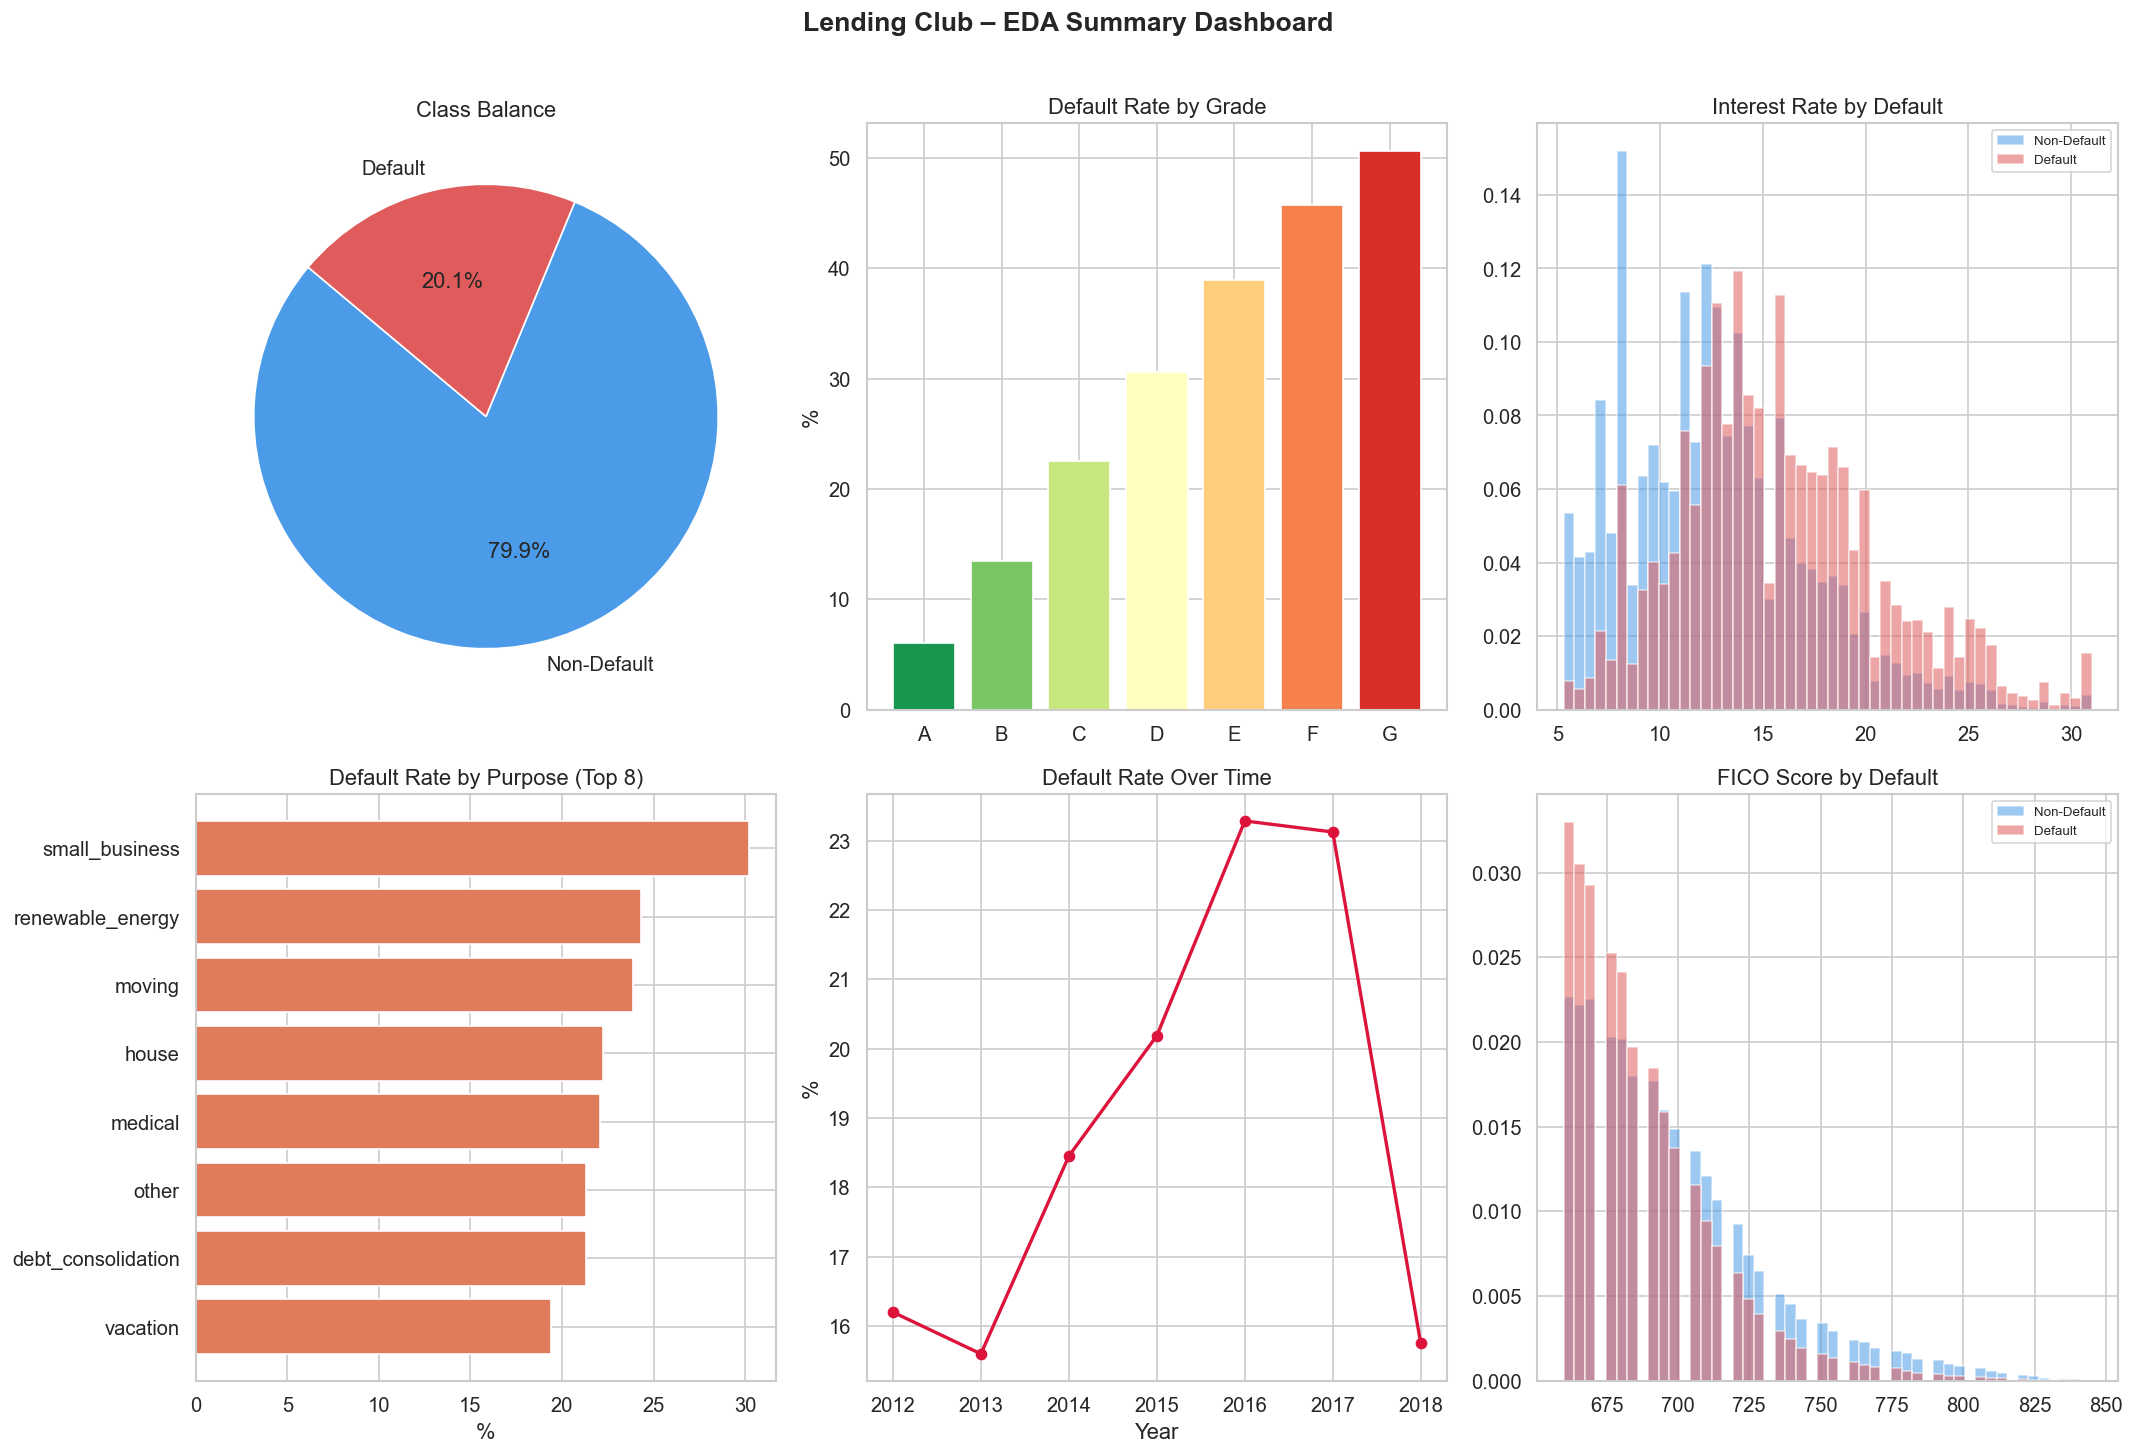

Dashboard saved → 09_summary_dashboard.png


In [22]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Lending Club – EDA Summary Dashboard", fontsize=16, fontweight="bold", y=1.01)

# Panel 1: Class imbalance
ax1 = fig.add_subplot(2, 3, 1)
counts = df["default"].value_counts()
ax1.pie(counts.values, labels=["Non-Default", "Default"],
        autopct="%1.1f%%", colors=["#4c9be8", "#e05c5c"],
        wedgeprops=dict(edgecolor="white"), startangle=140)
ax1.set_title("Class Balance")

# Panel 2: Default rate by grade
if "grade" in df.columns:
    ax2 = fig.add_subplot(2, 3, 2)
    gdr = df.groupby("grade")["default"].mean().sort_index() * 100
    ax2.bar(gdr.index, gdr.values,
            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(gdr))))
    ax2.set_title("Default Rate by Grade")
    ax2.set_ylabel("%")

# Panel 3: int_rate distribution by default
if "int_rate" in df.columns:
    ax3 = fig.add_subplot(2, 3, 3)
    for val, label, color in [(0, "Non-Default", "#4c9be8"), (1, "Default", "#e05c5c")]:
        ax3.hist(df[df["default"]==val]["int_rate"].dropna(),
                 bins=50, alpha=0.55, label=label, color=color, density=True)
    ax3.set_title("Interest Rate by Default")
    ax3.legend(fontsize=8)

# Panel 4: Default rate by purpose (top 8)
if "purpose" in df.columns:
    ax4 = fig.add_subplot(2, 3, 4)
    pdr = (df.groupby("purpose")["default"]
             .mean().sort_values(ascending=False).head(8) * 100)
    ax4.barh(pdr.index[::-1], pdr.values[::-1], color="#e07b5c")
    ax4.set_title("Default Rate by Purpose (Top 8)")
    ax4.set_xlabel("%")

# Panel 5: Temporal default rate
if "issue_d" in df.columns:
    ax5 = fig.add_subplot(2, 3, 5)
    yr_dr = df.groupby(df["issue_d"].dt.year)["default"].mean() * 100
    ax5.plot(yr_dr.index, yr_dr.values, marker="o", color="crimson", linewidth=2)
    ax5.set_title("Default Rate Over Time")
    ax5.set_xlabel("Year")
    ax5.set_ylabel("%")

# Panel 6: FICO vs default
if "fico_range_low" in df.columns:
    ax6 = fig.add_subplot(2, 3, 6)
    for val, label, color in [(0, "Non-Default", "#4c9be8"), (1, "Default", "#e05c5c")]:
        ax6.hist(df[df["default"]==val]["fico_range_low"].dropna(),
                 bins=50, alpha=0.55, label=label, color=color, density=True)
    ax6.set_title("FICO Score by Default")
    ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig("09_summary_dashboard.png", bbox_inches="tight")
plt.show()
print("Dashboard saved → 09_summary_dashboard.png")

###### The dashboard confirms the six key signals identified through EDA: class imbalance (~20% default rate), grade monotonicity, interest rate separation, purpose-level risk variation, temporal drift, and FICO score separation.

### 4.2. Key Findings Report

Tabular summary of all key EDA findings, ready for the modelling brief.

In [23]:
findings = {
    "Dataset size":                 f"{df.shape[0]:,} rows × {df.shape[1]} columns (post-filter)",
    "Target variable":              "loan_status → binary default (1=Charged Off)",
    "Class imbalance":              f"~{df['default'].mean()*100:.1f}% default rate",
    "High-null columns dropped":    "All columns with >60% missingness",
    "Strongest default predictors": "grade/sub_grade, int_rate, dti, FICO, purpose",
    "Leakage columns flagged":      str(len([c for c in LEAKAGE_COLS if c in df.columns])),
    "Non-stationarity":             "Default rate, DTI, and int_rate shift over time — use out-of-time splits",
    "Seasonality":                  "Q4/Dec peak in loan origination volume",
    "Recommended eval metric":      "Log-loss (probability calibration critical for credit scoring)",
    "Class imbalance handling":     "SMOTE or class-weighted models recommended",
}

report = pd.DataFrame(list(findings.items()), columns=["Finding", "Detail"])
report.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Finding,Detail
Dataset size,"1,305,524 rows × 108 columns (post-filter)"
Target variable,loan_status → binary default (1=Charged Off)
Class imbalance,~20.1% default rate
High-null columns dropped,All columns with >60% missingness
Strongest default predictors,"grade/sub_grade, int_rate, dti, FICO, purpose"
Leakage columns flagged,11
Non-stationarity,"Default rate, DTI, and int_rate shift over time — use out-of-time splits"
Seasonality,Q4/Dec peak in loan origination volume
Recommended eval metric,Log-loss (probability calibration critical for credit scoring)
Class imbalance handling,SMOTE or class-weighted models recommended
